# **Port Charles stress test case**

### **1. Parameter file**

All the information required to run a case are prescribed in the *BG_param.txt* file.
- Topography/bathymetry
- Surface roughness
- Boundary conditions (river injections, tide...)
- Forcing (rainfall, surface pressure)
- Grid resolution
- Simulation period and outputs
- Model specific parameters
> See parameters section of the manual for details https://cyprienbosserelle.github.io/BG_Flood/ParametersList-py/
---


### **2. Parameter file structure**

The following lines define a baseline BG_param.txt file. The corresponding input files are available in the Tutorial directory.
Have a look into them: *.nc in QGIS or Python, *.txt in text editor
> Note: The order of the input keys has no importance. The sections are not necessary and are added to improve readability

```markdown
# Port Charles stress test 

################
# Topography/Bathymetry
################
dem = PortCharles_DEM.nc?z

################
# Grid refinement
################
dx = 32.0;

################
# Forcing
################
# Rainfall prescribed in mm/h as
# 1. Uniform rainfall: tab delimited timeseries *.txt file [time rainfall]
# 2. Spatially varying: Mapped as multi-time *.nc (netcdf) file. 
rain = rain.txt

################
# Roughness
################
# Multiple surface roughness models exist: Here we use the dynamic Smart (2012) model
frictionmodel = 1
roughness = 0.04

################
# Boundaries
################
# Main types of boundaries depending on the flag
# 0: Wall
# 1: Zero-gradient (Neumann): Used for open outletw
# 2: Fixed value (Dirichlet) - Requires timeseries file: Used for tides
# 3: Absorbing wave - Same as 2 but more stable numerically (allows waves to exit the domain)
left = 0;
right = 0;
top = 0;
bot = 0;

################
# Solver parameters
################

engine = 2
vmax=16.0

################
# output parameters
################

endtime = 4800.0
outputtimestep = 300.00;

outvars = h, zs, u, v, hmax, zsmax, Umax, hUmax;

outfile = Port_Charles_dx32m.nc
```
---

### **3. First BG-Flood run**

We have 2 options to execute BG-Flood
1. Terminal command: move to the project directory and run 
```
path\to\BG_Flood\BG_Flood.exe
```

2. Copy paste the content of the compiled directory `path\to\BG_Flood\` (all of it!) and double click `BG_Flood.exe`

---

### **4. Checking the results**

#### 1. In QGIS
To quickly check the output, simply drag and drop the output file into QGIS.

Try to open the results ***Port_Charles_dx32m.nc*** and read the variable ***h_P0***.
- Make sure the CRS is set to "EPSG:2193" - CRS can be chosen after clicking at the bottom right of the QGIS window
- Most visualisation features can be tuned in the ***Styling Panel*** window
- You can navigate across the different timesteps via the Band dropdown list

> The output variables have a suffix *_P0. We will come back to it later

#### 2. In Python
The conda environment should already be installed at this stage. If not, refer to section 3 of the *BG_Flood_introduction.ipynb*.

We will use the packages xarray and rioxarray to open the files and plot as follow

In [4]:
#%%% IMPORT PACKAGES
import xarray as xr
import rioxarray
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt

#import folium


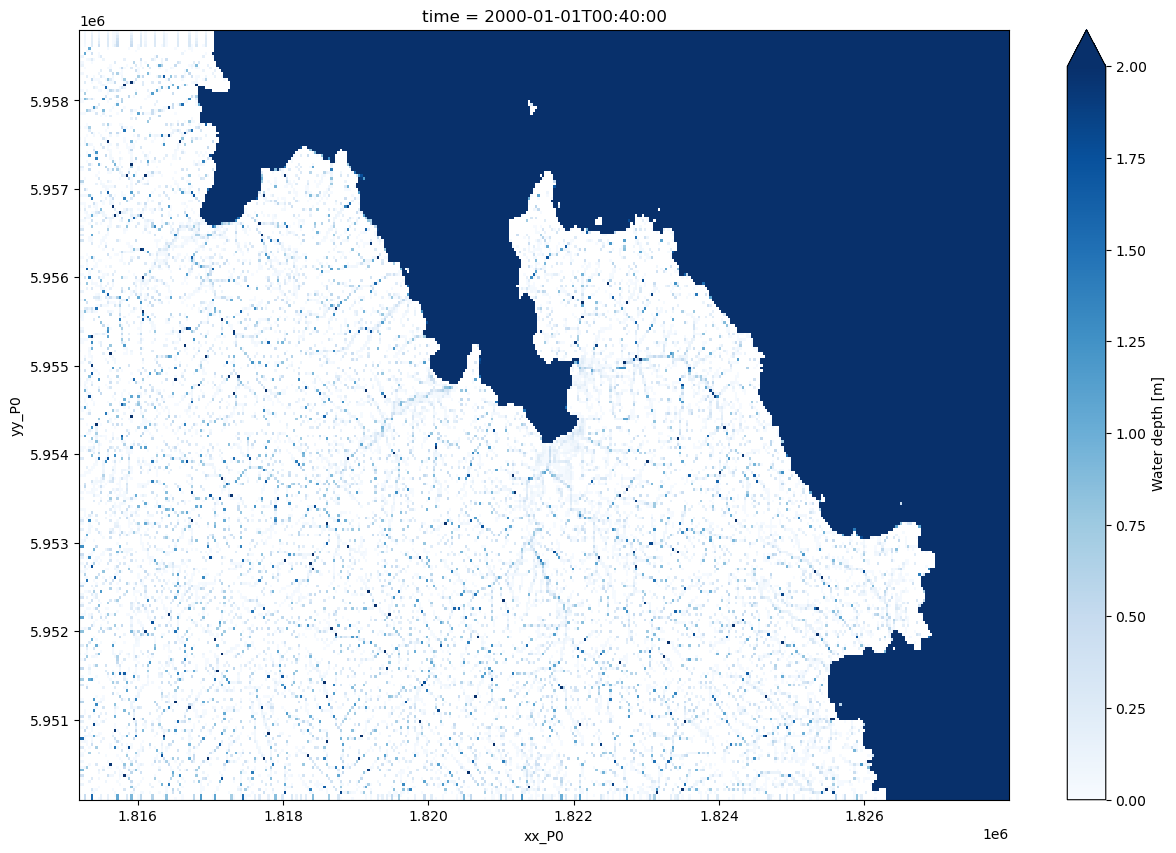

In [ ]:
#%%% SIMPLE PLOT



# Replace with the path to your output file.
BGout_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32m.nc"
#BGout_path = "\path\to\Tutorial_1\Port_Charles_dx32m.nc"

# Open the dataset containing all your variables with xarray.
ds = xr.open_dataset(BGout_path)

# All the variables composing an xarray dataset are named dataarray.
# With xarray, you can immediately plot a timestep of a dataarray as follow:
timestep = 4
ds["h_P0"][timestep].plot(vmin=0, vmax=2, cmap="Blues")

# If you want to have more control on the plot, you can create a figure and axis with matplotlib, and then plot the dataarray on that axis.
fig, ax = plt.subplots(figsize=(15, 10))
ds["h_P0"][timestep].plot(ax=ax, vmin=0, vmax=2, cmap="Blues")


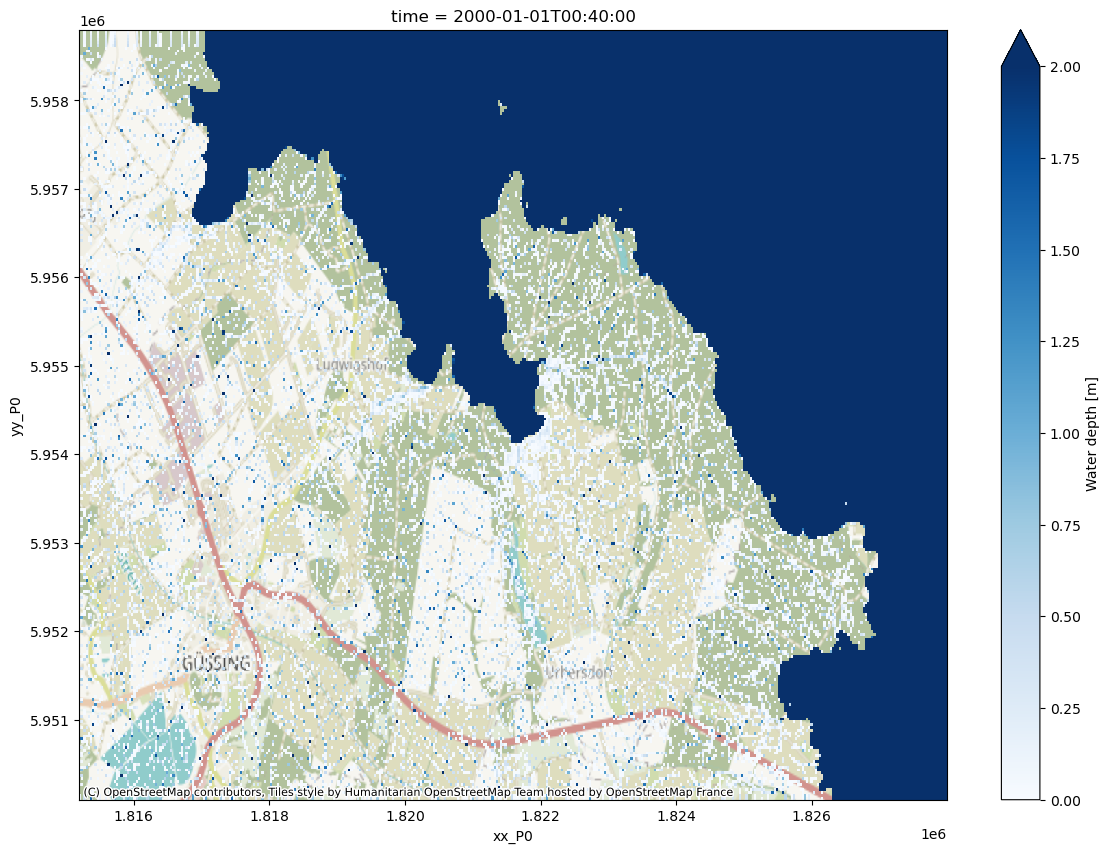

In [ ]:
# With contextily, it is easiy to add a background.
# Try to add OpenStreetMap as background

# Create figure
timestep = 4
fig, ax = plt.subplots(figsize=(15, 10))
ds["h_P0"][timestep].plot(ax=ax, vmin=0, vmax=2, cmap="Blues")
ctx.add_basemap(ax)

In [ ]:
#%%% Additional post-processing steps

# Rename variables and dimensions to remove level suffixes, and add CRS information.

# Function to read in the output file and rename the variables.
def prep_BGout(file_path, list_variables=["h"], crs="EPSG:2193"):
    print(f" # Reading input file {file_path}...")
    with xr.open_dataset(file_path) as ds:
        for var in list_variables:
            print(f"    . Treatment of variable {var}...")
            lvl_str = f"P0"
            da_lvl = ds[f"{var}_{lvl_str}"]
            da_lvl = da_lvl.rename({
                f"yy_{lvl_str}": "y",
                f"xx_{lvl_str}": "x",
            })
            da_lvl = da_lvl.rename(var)
            da_lvl_out = da_lvl.copy()
            y = da_lvl_out.y
            x = da_lvl_out.x

            da_lvl_out = da_lvl_out.rio.write_crs(crs, inplace=True)

        dsout[var] = da_lvl_out

    dsout.rio.write_crs(crs, inplace=True)
    dsout.rio.write_coordinate_system(inplace=True)

    return dsout


# Replace with the path to your output file.
BGout_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov.nc"
#BGout_path = "\path\to\Tutorial_1\Port_Charles_dx32m.nc"
save_flag = False

# List of variables to concatenate across levels.
list_variables = ["h", "u", "v", "zs", "hmax", "zsmax", "Umax"]

# Initialise output file
dsout = xr.Dataset()

# Rename variables and dimensions to remove 

dsout = prep_BGout(BGout_path, list_variables, crs="EPSG:2193")
# Now all the variable are cleaned and can be saved if desired by setting save_flag=True.
if save_flag:
    outfile_path = "\path\to\Tutorial_1\Port_Charles_dx32m_cleaned.nc"
    dsout.to_netcdf(outfile_path)


 # Reading input file /mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov.nc...
    . Treatment of variable h...
    . Treatment of variable u...
    . Treatment of variable v...
    . Treatment of variable zs...
    . Treatment of variable hmax...
    . Treatment of variable zsmax...
    . Treatment of variable Umax...
